In [6]:


import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup, AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from tqdm import tqdm

# -----------------------------
# 1. GPU Setup
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2. Load Dataset
# -----------------------------
df = pd.read_csv(r"/content/FakeNewsNet.csv (1) (1).zip")
df = df.fillna("")

if "text" in df.columns:
    df["content"] = df["title"] + " " + df["text"]
else:
    df["content"] = df["title"]

# -----------------------------
# 3. Balance Dataset
# -----------------------------
df_fake = df[df["real"] == 0]
df_real = df[df["real"] == 1]

df_fake_upsampled = resample(
    df_fake,
    replace=True,
    n_samples=len(df_real),
    random_state=42
)

df_balanced = pd.concat([df_fake_upsampled, df_real]).sample(frac=1, random_state=42)

X = df_balanced["content"].tolist()
y = df_balanced["real"].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------
# 4. Tokenization
# -----------------------------
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # FIXED (modern tokenizer usage)
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

train_dataset = NewsDataset(X_train, y_train, tokenizer)
test_dataset = NewsDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# -----------------------------
# 5. Model Setup
# -----------------------------
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)
model = model.to(device)

# Class weights
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

# FIXED AdamW import (transformers version)
optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 3
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, 0, total_steps)

# -----------------------------
# 6. Training
# -----------------------------
for epoch in range(epochs):
    model.train()
    loop = tqdm(train_loader, leave=True)

    for batch in loop:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

# -----------------------------
# 7. Evaluation
# -----------------------------
model.eval()
preds, true_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predictions = torch.argmax(logits, dim=-1)

        preds.extend(predictions.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print("\nAccuracy:", accuracy_score(true_labels, preds))
print("\nClassification Report:\n", classification_report(true_labels, preds, target_names=["Fake", "Real"]))

# -----------------------------
# 8. Prediction Function
# -----------------------------
def check_news(news_text):
    model.eval()

    # FIXED tokenizer usage
    encoding = tokenizer(
        news_text,
        add_special_tokens=True,
        max_length=256,
        truncation=True,
        padding="max_length",
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

        pred = torch.argmax(probs, dim=-1).item()
        confidence = torch.max(probs).item() * 100

    label = "Real News" if pred == 1 else "Fake News"

    print("\nNews:", news_text)
    print("Prediction:", label, f"(Confidence: {confidence:.2f}%)")

    return label, confidence

# -----------------------------
# 9. Test Examples
# -----------------------------
check_news("Bill Gates installs microchips in people through COVID-19 vaccines.")
check_news("Elon Musk buys the Pacific Ocean and plans to turn it into a private lake.")
check_news("Aliens landed in New York yesterday!")
check_news("Apple announces new iPhone models with improved battery life.")
check_news("Drinking soda daily can cure all diseases, claim scientists.")




Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 3: 100%|██████████| 1745/1745 [10:03<00:00,  2.89it/s, loss=0.00198]



Accuracy: 0.9174430270890067

Classification Report:
               precision    recall  f1-score   support

        Fake       0.89      0.95      0.92      3489
        Real       0.95      0.89      0.91      3488

    accuracy                           0.92      6977
   macro avg       0.92      0.92      0.92      6977
weighted avg       0.92      0.92      0.92      6977


News: Bill Gates installs microchips in people through COVID-19 vaccines.
Prediction: Fake News (Confidence: 72.44%)

News: Elon Musk buys the Pacific Ocean and plans to turn it into a private lake.
Prediction: Real News (Confidence: 99.51%)

News: Aliens landed in New York yesterday!
Prediction: Fake News (Confidence: 99.52%)

News: Apple announces new iPhone models with improved battery life.
Prediction: Real News (Confidence: 99.70%)

News: Drinking soda daily can cure all diseases, claim scientists.
Prediction: Fake News (Confidence: 76.30%)


('Fake News', 76.30495429039001)

In [7]:
model.save_pretrained("fake_news_model")
tokenizer.save_pretrained("fake_news_model")

('fake_news_model/tokenizer_config.json',
 'fake_news_model/special_tokens_map.json',
 'fake_news_model/vocab.txt',
 'fake_news_model/added_tokens.json')

In [13]:
import gradio as gr

ui = gr.Interface(
    fn=check_news,
    inputs=gr.Textbox(lines=3, placeholder="Paste a news article or headline here..."),
    outputs="text",
    title="📰 Fake News Detector",
    description="Detect whether news is real or fake using a DistilBERT model."
)

ui.launch(share=True)  # share=True gives you a public link


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://70ff684cb4c19df97f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


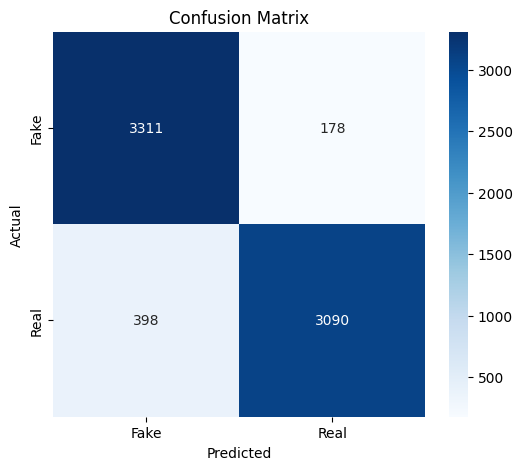

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()